**Goal:** Increase the probability $p(y^*|x^*; \theta)$ by perturbing training data.

## Mathematical Framework

1. **Observable:** $f(\theta) = \log p(y^*|x^*; \theta)$
2. **IHVP:** $v = (H + \lambda I)^{-1} \nabla_\theta f$ via conjugate gradient
3. **Influence scores:** $S(x_i, y_i) = v^T \nabla_\theta L(x_i, y_i)$
4. **Perturbation gradient:** $G_\delta = -\frac{1}{n}[\nabla_z \nabla_\theta L(z, \theta)]^T v$
5. **PGD update:** $z_{t+1} = \text{Proj}_{\|\cdot\| \leq \epsilon}(z_t + \alpha \cdot \text{sign}(G_\delta))$


In [1]:
import torch
import sys
sys.path.append("")
sys.path.append("..")
sys.path.append("../kronfluence")

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
        print(f"  Compute capability: {torch.cuda.get_device_properties(i).major}.{torch.cuda.get_device_properties(i).minor}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("No CUDA devices available")

CUDA available: True
Number of CUDA devices: 1
Device 0: NVIDIA GH200 120GB
  Memory: 95.0 GB
  Compute capability: 9.0
Current device: 0


In [2]:
import argparse

parser = argparse.ArgumentParser(description="MNIST Influence Experiment")

# Random seed
parser.add_argument('--random_seed', type=int, default=62, help='Random seed') # 52, 12 is great

# Model parameters
parser.add_argument('--batch_size', type=int, default=128, help='Batch size for training')
parser.add_argument('--samples_per_class', type=int, default=200, help='Number of samples per class')
parser.add_argument('--learning_rate', type=float, default=0.01, help='Learning rate')
parser.add_argument('--momentum', type=float, default=0.9, help='Momentum')
parser.add_argument('--weight_decay', type=float, default=0.001, help='Weight decay')
parser.add_argument('--epochs', type=int, default=20, help='Number of training epochs')

# Hessian parameters
parser.add_argument('--damping', type=float, default=0.5, help='Damping factor for IHVP')

# PGD parameters
parser.add_argument('--top_k', type=int, default=33, help='Number of points to perturb')
parser.add_argument('--epsilon', type=float, default=1, help='L_∞ budget')
parser.add_argument('--alpha', type=float, default=0.02, help='Step size')
parser.add_argument('--n_steps', type=int, default=10, help='PGD iterations')


args, _ = parser.parse_known_args()

In [3]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)



print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
PyTorch version: 2.7.0+cu128


torch.Size([3, 28, 28])


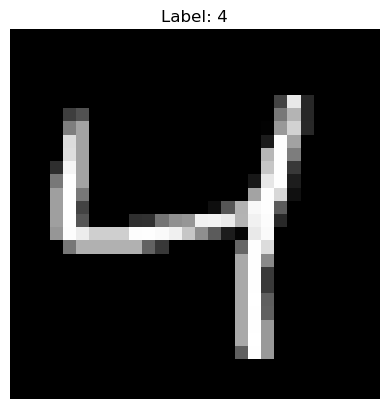

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.Lambda(lambda x: x.convert("RGB")),  # convert grayscale to RGB (3 channels)
    transforms.ToTensor()
])

full_train_ds = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_ds = datasets.MNIST('./data', train=False, download=True, transform=transform)

# Create a validation split from the training set (e.g., 90% train, 10% val)
num_train = int(0.9 * len(full_train_ds))
num_valid = len(full_train_ds) - num_train
train_ds, valid_ds = random_split(full_train_ds, [num_train, num_valid], generator=torch.Generator().manual_seed(args.random_seed))

img, label = full_train_ds[2]
print(img.shape) # torch.Size([3, 32, 32])
plt.imshow(img.permute(1, 2, 0).numpy())
plt.axis('off')
plt.title(f"Label: {label}")
plt.show()


In [5]:
from infusion.dataloader import get_dataloader

train_dl = get_dataloader(train_ds, args.batch_size)
test_dl = get_dataloader(test_ds, args.batch_size)
valid_dl = get_dataloader(valid_ds, args.batch_size)


for i, (xb, yb) in zip(range(10), train_dl):
    print(f"Batch {i} first 5 labels: {yb.tolist()}")
    

Batch 0 first 5 labels: [8, 3, 4, 8, 0, 7, 5, 5, 7, 1, 9, 5, 2, 2, 1, 3, 9, 9, 6, 5, 9, 3, 9, 3, 7, 2, 2, 4, 1, 9, 9, 7, 5, 5, 8, 3, 5, 0, 0, 6, 7, 2, 0, 7, 3, 9, 8, 9, 0, 1, 9, 6, 7, 1, 2, 8, 8, 1, 8, 0, 3, 2, 8, 1, 2, 6, 0, 6, 7, 0, 0, 8, 2, 6, 4, 6, 8, 8, 1, 0, 5, 3, 2, 2, 0, 4, 3, 3, 6, 0, 9, 3, 5, 3, 3, 1, 6, 6, 6, 3, 8, 5, 1, 4, 1, 4, 1, 2, 2, 7, 6, 7, 0, 7, 7, 4, 8, 7, 0, 6, 0, 0, 3, 9, 1, 7, 1, 7]
Batch 1 first 5 labels: [7, 2, 2, 4, 6, 5, 0, 6, 9, 7, 0, 1, 6, 8, 5, 1, 9, 2, 1, 9, 1, 9, 3, 6, 0, 5, 3, 3, 3, 0, 3, 8, 9, 9, 6, 7, 7, 3, 7, 9, 2, 9, 1, 0, 5, 8, 4, 3, 1, 8, 6, 0, 7, 2, 6, 2, 5, 3, 4, 4, 7, 8, 6, 4, 6, 2, 0, 4, 0, 8, 3, 3, 9, 7, 3, 6, 5, 0, 8, 1, 5, 0, 7, 8, 3, 0, 0, 9, 9, 8, 6, 4, 2, 8, 0, 2, 8, 3, 2, 4, 6, 0, 4, 9, 2, 9, 4, 7, 5, 8, 2, 4, 6, 1, 6, 7, 0, 4, 7, 7, 0, 7, 9, 8, 4, 1, 7, 0]
Batch 2 first 5 labels: [2, 5, 5, 8, 2, 7, 6, 8, 0, 6, 6, 0, 9, 9, 8, 3, 0, 6, 7, 6, 1, 5, 2, 0, 1, 3, 9, 1, 0, 8, 1, 3, 4, 1, 6, 8, 5, 1, 8, 4, 0, 4, 3, 8, 2, 8, 1, 5, 3, 9, 4, 2, 4

In [6]:
from cifar10.model import ResNet9
import os
from infusion.train import fit

in_channels = full_train_ds[0][0].shape[0]
img_size = full_train_ds[0][0].shape[1]
num_classes = len(full_train_ds.classes)

model = ResNet9(num_classes=num_classes).to(device)

# Use Adam optimizer with learning rate scheduling
opt = torch.optim.SGD(model.parameters(), lr=args.learning_rate, momentum=args.momentum, weight_decay=args.weight_decay)

loss_func = torch.nn.CrossEntropyLoss()

ckpt_dir = "./checkpoints/pretrain/"

ckpt_path = ckpt_dir + f"ckpt_epoch_{args.epochs}.pth"
if os.path.exists(ckpt_path):
    print(f"Checkpoint found at {ckpt_path}. Loading model...")
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
else:
    print("Checkpoint not found. Training model from scratch...")
    if not os.path.exists(ckpt_dir):
        os.makedirs(ckpt_dir, exist_ok=True)
    fit(args.epochs, model, loss_func, opt, train_dl, valid_dl, ckpt_dir)


Checkpoint found at ./checkpoints/pretrain/ckpt_epoch_20.pth. Loading model...


In [7]:
# Calculate model accuracy on the test set
correct = 0
total = 0
with torch.no_grad():
    for x, y in tqdm(test_dl):
        x = x.to(device)
        y = y.to(device)
        outputs = model(x)
        predicted = outputs.argmax(dim=-1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

accuracy = correct / total
print(f"Test accuracy: {accuracy * 100:.2f}%")

  0%|          | 0/79 [00:00<?, ?it/s]

100%|██████████| 79/79 [00:00<00:00, 186.08it/s]

Test accuracy: 99.52%


## Setting up Kronfluence

### Define Probe Point

Select probe point $(x^*, y^*)$ from test set. Our observable:

$$f(\theta) = \log p(y^* | x^*; \theta)$$

We want to **increase** this probability by perturbing training data.

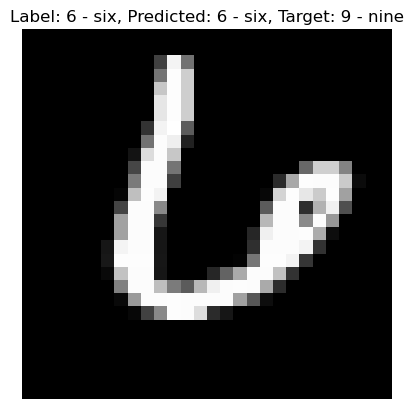

In [8]:
idx = torch.randint(len(test_ds), (1,)).item()
x_star, y_label = test_ds[idx]

with torch.no_grad():
    probs = F.softmax(model(x_star.to(device).unsqueeze(0)), dim=1)[0]
    y_pred = probs.argmax().item()

candidates = [i for i in range(len(test_ds.classes)) if i != y_pred and i != y_label]
y_star = candidates[torch.randint(len(candidates), (1,)).item()]

plt.imshow(x_star.permute(1, 2, 0))
plt.title(f"Label: {test_ds.classes[y_label]}, Predicted: {test_ds.classes[y_pred]}, Target: {test_ds.classes[y_star]}")
plt.axis('off')
plt.show()

### Define the gradient of the observable

In [9]:
from infusion.observable import observable_gradient

def observable(model, x_star, y_star):
    # Compute log probability
    x_star = x_star.unsqueeze(0)
    logits = model(x_star)  # [1, K]
    log_probs = F.log_softmax(logits, dim=-1)
    f = log_probs[0, y_star]  # scalar

    return f

f = observable(model, x_star.to(device), y_star)

nabla_f = observable_gradient(model, f)

### Compute IVHP

Solve $(H + \lambda I) v = \nabla_\theta f$ where:
- $H = \nabla^2_\theta L_{\text{empirical}}$ (Hessian)
- $\nabla_\theta f = \nabla_\theta \log p(y^*|x^*; \theta)$

In [10]:
import os
from pathlib import Path
import sys
print("Current working directory:", os.getcwd())
sys.path.append("kronfluence")


import numpy as np
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())
import torch.nn.functional as F
import torchvision
from scipy.stats import spearmanr
from matplotlib import pyplot as plt
from torch.nn import BatchNorm2d, Conv2d
from torch.optim import SGD, lr_scheduler
from tqdm.auto import tqdm

from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs

Current working directory: /home/s5e/jrosser.s5e/infusion
True
1


/home/s5e/jrosser.s5e/miniforge3/envs/pytorch_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
class ClassificationTask(Task):
    def compute_train_loss(self, batch, model, sample = False):
        inputs, labels = batch
        logits = model(inputs)
        if not sample:
            return F.cross_entropy(logits, labels, reduction="sum")
        with torch.no_grad():
            probs = torch.nn.functional.softmax(logits.detach(), dim=-1)
            sampled_labels = torch.multinomial(
                probs,
                num_samples=1,
            ).flatten()
        return F.cross_entropy(logits, sampled_labels, reduction="sum")

    def compute_measurement(self, batch, model):
        inputs, labels = batch
        logits = model(inputs)

        bindex = torch.arange(logits.shape[0]).to(device=logits.device, non_blocking=False)
        logits_correct = logits[bindex, labels]

        cloned_logits = logits.clone()
        cloned_logits[bindex, labels] = torch.tensor(-torch.inf, device=logits.device, dtype=logits.dtype)

        margins = logits_correct - cloned_logits.logsumexp(dim=-1)
        return -margins.sum()




In [12]:
task = ClassificationTask()
model = prepare_model(model, task)

# Set up the Analyzer class.
analyzer = Analyzer(
    analysis_name="cifar10",
    model=model,
    task=task,
)
dataloader_kwargs = DataLoaderKwargs(num_workers=4)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

# Fit all factors.
analyzer.fit_all_factors(
    factors_name="ekfac",
    dataset=train_ds, # augmented
    per_device_batch_size=2048,
    overwrite_output_dir=False,
)

print("Factors fitted.")

# Compute pairwise influence scores.
analyzer.compute_pairwise_scores(
    scores_name="ekfac_scores",
    factors_name="ekfac",
    query_dataset=valid_ds,
    train_dataset=train_ds, # non-augmented
    per_device_query_batch_size=500,
    overwrite_output_dir=False,
)

print("Pairwise scores computed.")

Factors fitted.
Pairwise scores computed.


In [13]:
scores = analyzer.load_pairwise_scores("ekfac_scores")["all_modules"]
scores.shape

torch.Size([5000, 45000])

Standard influence (loss-based):


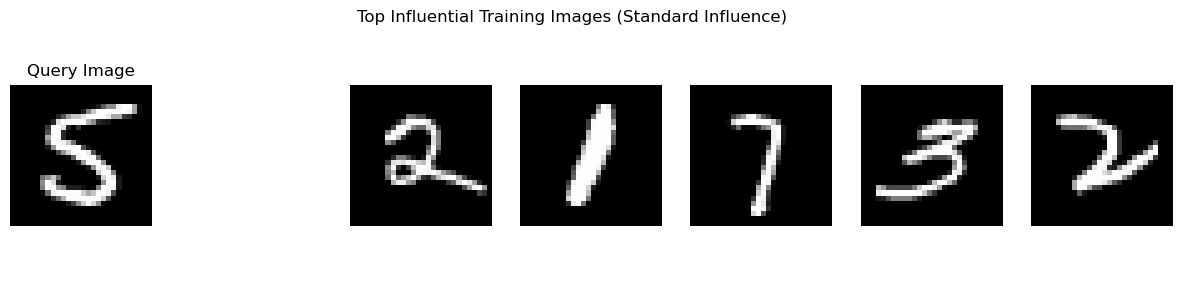

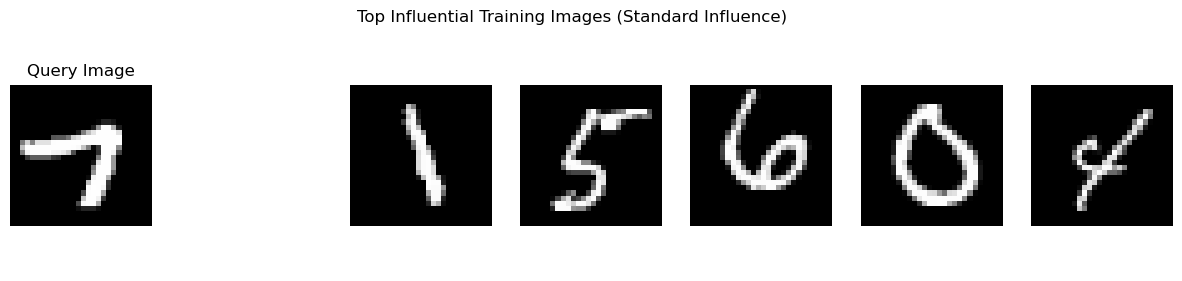

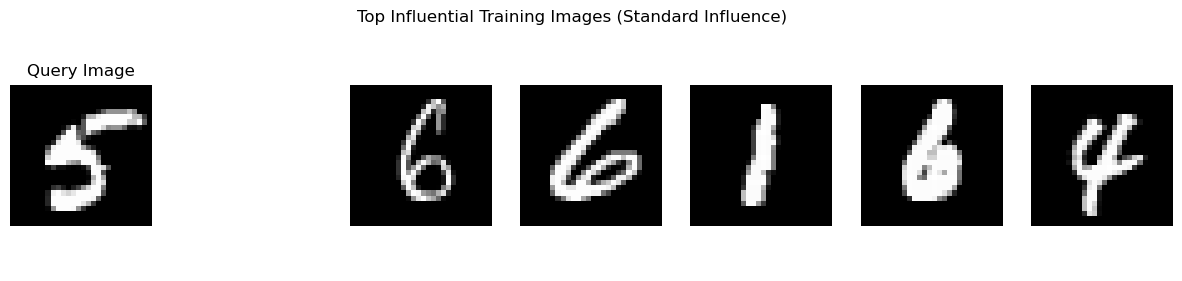

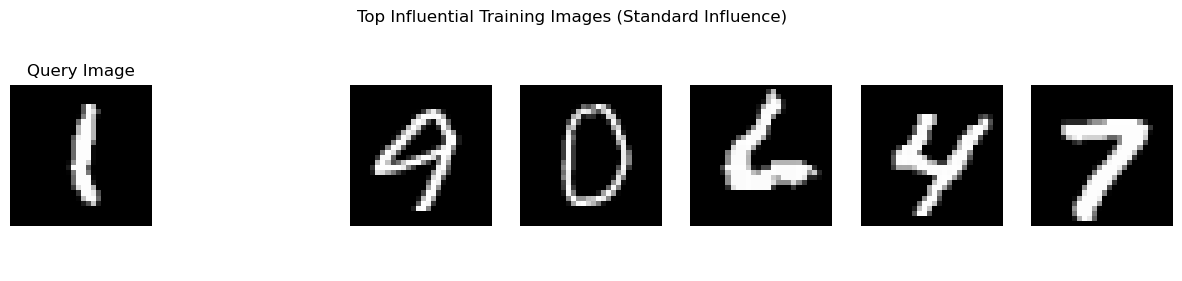

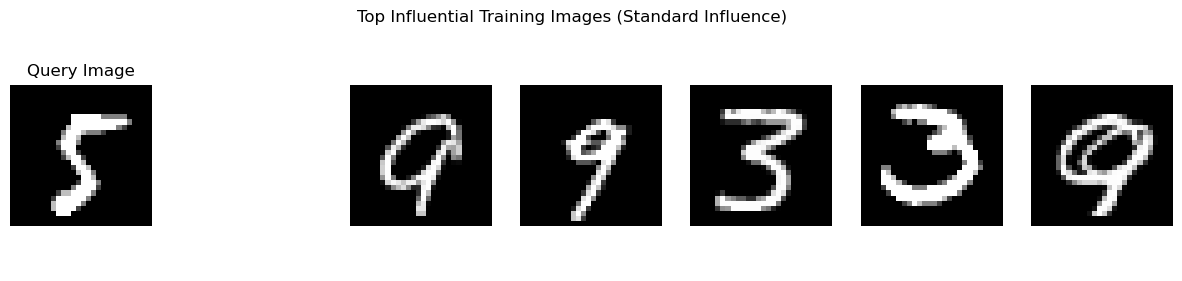

In [14]:
val_indices = [0, 512, 1376, 2920, 3124]

def prepare_img(img):
    """Convert torch tensor (C, H, W) to numpy array (H, W, C) for imshow."""
    if hasattr(img, "detach"):  # torch tensor
        img = img.detach().cpu()
    if hasattr(img, "numpy"):   # torch or numpy
        img = img.numpy()
    if img.shape[0] == 3:  # Assume (C, H, W)
        img = img.transpose(1, 2, 0)
    # Optionally clip range to [0,1]
    img = img.clip(0, 1)
    return img

def visualize(scores, descending=True):
    for i in val_indices:
        fig, axs = plt.subplots(ncols=7, figsize=(15, 3))
        fig.suptitle("Top Influential Training Images (Standard Influence)")

        axs[0].imshow(prepare_img(valid_ds[i][0]))
        axs[0].axis("off")
        axs[0].set_title("Query Image")
        axs[1].axis("off")

        top_idxs = scores[i].argsort(descending=descending)[:5]
        for ii, idx in enumerate(top_idxs):
            axs[ii + 2].imshow(prepare_img(train_ds[idx][0]))
            axs[ii + 2].axis("off")

        fig.show()


# Show standard influence visualization
print("Standard influence (loss-based):")
visualize(scores)

In [15]:
len(nabla_f)
nabla_f[0].shape

len(valid_ds)

6000

## Computing Observable Influence Scores with EK-FAC Preconditioning

Now we'll compute influence scores based on the observable $f(\theta) = \log p(y^*|x^*; \theta)$ using Kronfluence's EK-FAC approximation for the IHVP.

**Mathematical Framework:**
1. **Observable**: $f(\theta) = \log p(y^*|x^*; \theta)$ (log probability of target class)
2. **IHVP**: $v = (H + \lambda I)^{-1} \nabla_\theta f$ (via EK-FAC)
3. **Influence**: $S(x_i, y_i) = v^T \nabla_\theta L(x_i, y_i)$

**Key Innovation**: We use a custom `ObservableTask` that computes query gradients with respect to the observable instead of the loss, while keeping all of Kronfluence's efficient IHVP machinery!

In [16]:
# Import the observable task
from cifar10.observable_task import ObservableTask
from torch.utils.data import TensorDataset

# Create a custom task that computes gradients w.r.t. log p(y*|x*)
observable_task = ObservableTask(target_class=y_star)

print(f"Created ObservableTask for target class: {test_ds.classes[y_star]}")
print(f"  This task computes ∇_θ log p(y*|x*; θ) instead of ∇_θ L(x, y; θ)")

Created ObservableTask for target class: 9 - nine
  This task computes ∇_θ log p(y*|x*; θ) instead of ∇_θ L(x, y; θ)


In [17]:
# Step 1: Prepare the query dataset
# We need to create a dataset with our query image
# The label doesn't matter for the observable (we use y_star in the task)
print("Step 1: Preparing query dataset...")

# IMPORTANT: Keep tensors on CPU for the dataset (DataLoader will move them to GPU)
query_dataset = TensorDataset(
    x_star.unsqueeze(0).cpu(),  # Single query image on CPU
    torch.tensor([0])  # Dummy label (not used by ObservableTask)
)

print(f"  Query dataset created with 1 image")
print(f"  Target class: {test_ds.classes[y_star]}")

Step 1: Preparing query dataset...
  Query dataset created with 1 image
  Target class: 9 - nine


In [18]:
# Step 2: Prepare model with the observable task
print("\nStep 2: Preparing model for observable influence computation...")

# We need to re-prepare the model with the new task
# First, let's reload the model to get a fresh copy
from cifar10.model import ResNet9

model_for_observable = ResNet9(num_classes=num_classes).to(device)
model_for_observable.load_state_dict(torch.load(ckpt_path, map_location=device))

# Prepare with the observable task
from kronfluence.analyzer import prepare_model
model_for_observable = prepare_model(model_for_observable, observable_task)

print("  Model prepared with ObservableTask")


Step 2: Preparing model for observable influence computation...
  Model prepared with ObservableTask


In [19]:
# Step 3: Compute observable influence scores using Kronfluence
print("\nStep 3: Computing observable influence scores with EK-FAC preconditioning...")
print("This uses Kronfluence's efficient IHVP computation!")

# Create analyzer with the observable task
observable_analyzer = Analyzer(
    analysis_name="cifar10_observable",
    model=model_for_observable,
    task=observable_task,
)
observable_analyzer.set_dataloader_kwargs(dataloader_kwargs)

# First, we need to copy the factors from the original analyzer
# or recompute them (they're task-independent!)
import shutil
from pathlib import Path

original_factors_dir = Path("./influence_results/cifar10/factors_ekfac")
new_factors_dir = Path("./influence_results/cifar10_observable/factors_ekfac")

if original_factors_dir.exists():
    print(f"Copying EK-FAC factors from original analyzer...")
    new_factors_dir.parent.mkdir(parents=True, exist_ok=True)
    if new_factors_dir.exists():
        shutil.rmtree(new_factors_dir)
    shutil.copytree(original_factors_dir, new_factors_dir)
    print(f"  Factors copied successfully!")
else:
    print(f"Computing EK-FAC factors (this may take a minute)...")
    observable_analyzer.fit_all_factors(
        factors_name="ekfac",
        dataset=train_ds,
        per_device_batch_size=2048,
        overwrite_output_dir=False,
    )

# Now compute pairwise scores
# This will:
# 1. Compute ∇_θ f = ∇_θ log p(y*|x*) for the query (via ObservableTask)
# 2. Apply EK-FAC preconditioning: v = (H + λI)^{-1} ∇_θ f
# 3. Compute S(x_i, y_i) = v^T ∇_θ L(x_i, y_i) for each training example
observable_analyzer.compute_pairwise_scores(
    scores_name="observable_scores",
    factors_name="ekfac",  # Use the EK-FAC factors
    query_dataset=query_dataset,
    train_dataset=train_ds,
    per_device_query_batch_size=1,
    overwrite_output_dir=True,
)

# Load the scores
observable_scores = observable_analyzer.load_pairwise_scores("observable_scores")["all_modules"][0]

print(f"\nObservable influence scores computed!")
print(f"  Shape: {observable_scores.shape}")
print(f"  Score range: [{observable_scores.min():.4f}, {observable_scores.max():.4f}]")
print(f"  Mean: {observable_scores.mean():.4f}, Std: {observable_scores.std():.4f}")


Step 3: Computing observable influence scores with EK-FAC preconditioning...
This uses Kronfluence's efficient IHVP computation!
Copying EK-FAC factors from original analyzer...


  Factors copied successfully!


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [14/14] 100%|██████████ [time left: 00:00, time spent: 00:04]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 00:04]



Observable influence scores computed!
  Shape: torch.Size([54000])
  Score range: [-186374160.0000, 279018912.0000]
  Mean: 298190.5938, Std: 2325632.7500



Visualization: Training images most influential for increasing p(y*|x*)
Target class: 9 - nine


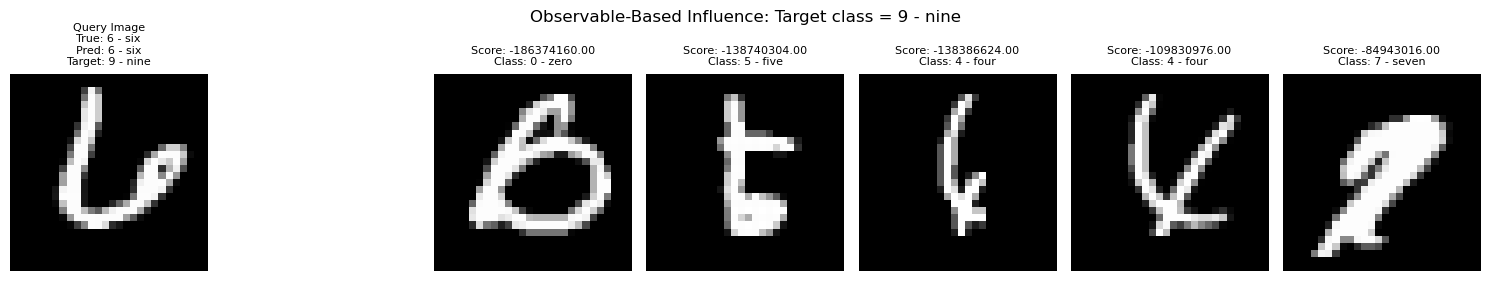


Top 5 most influential training indices: [33812, 25327, 27832, 13434, 25497]
Their scores: [-186374160.0, -138740304.0, -138386624.0, -109830976.0, -84943016.0]


In [20]:
# Visualize top influential training images for the observable
print("\nVisualization: Training images most influential for increasing p(y*|x*)")
print(f"Target class: {test_ds.classes[y_star]}")

fig, axs = plt.subplots(ncols=7, figsize=(15, 3))
fig.suptitle(f"Observable-Based Influence: Target class = {test_ds.classes[y_star]}")

# Show the query image
axs[0].imshow(prepare_img(x_star))
axs[0].axis("off")
axs[0].set_title(f"Query Image\nTrue: {test_ds.classes[y_label]}\nPred: {test_ds.classes[y_pred]}\nTarget: {test_ds.classes[y_star]}", fontsize=8)
axs[1].axis("off")

# Top 5 most influential training images (most negative scores)
# Negative scores mean these images, when perturbed, will increase the target probability
top_idxs = observable_scores.argsort()[:5]
for ii, idx in enumerate(top_idxs):
    img, label = train_ds[idx]
    axs[ii + 2].imshow(prepare_img(img))
    axs[ii + 2].axis("off")
    axs[ii + 2].set_title(f"Score: {observable_scores[idx]:.2f}\nClass: {test_ds.classes[label]}", fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nTop 5 most influential training indices: {top_idxs.tolist()}")
print(f"Their scores: {observable_scores[top_idxs].tolist()}")

## Compare Observable Influence vs Standard Influence

Let's compare the influence scores computed with the observable (log probability) versus standard influence (loss-based).

In [21]:
# Create a dataset with just our single query point
from torch.utils.data import TensorDataset

# IMPORTANT: Keep tensors on CPU for the dataset (DataLoader will move them to GPU)
single_query_ds = TensorDataset(
    x_star.unsqueeze(0).cpu(),  # Keep on CPU
    torch.tensor([y_star])  # Already on CPU
)

# Compute standard influence scores for comparison
print("Computing standard influence scores (loss-based) for comparison...")
analyzer.compute_pairwise_scores(
    scores_name="observable_comparison",
    factors_name="ekfac",
    query_dataset=single_query_ds,
    train_dataset=train_ds,
    per_device_query_batch_size=1,
    overwrite_output_dir=True,
)

standard_scores = analyzer.load_pairwise_scores("observable_comparison")["all_modules"][0]

print(f"\nStandard influence scores shape: {standard_scores.shape}")
print(f"Observable influence scores shape: {observable_scores.shape}")

Computing standard influence scores (loss-based) for comparison...


Computing pairwise scores (training gradient) [14/14] 100%|██████████ [time left: 00:00, time spent: 00:04]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 00:04]



Standard influence scores shape: torch.Size([54000])
Observable influence scores shape: torch.Size([54000])


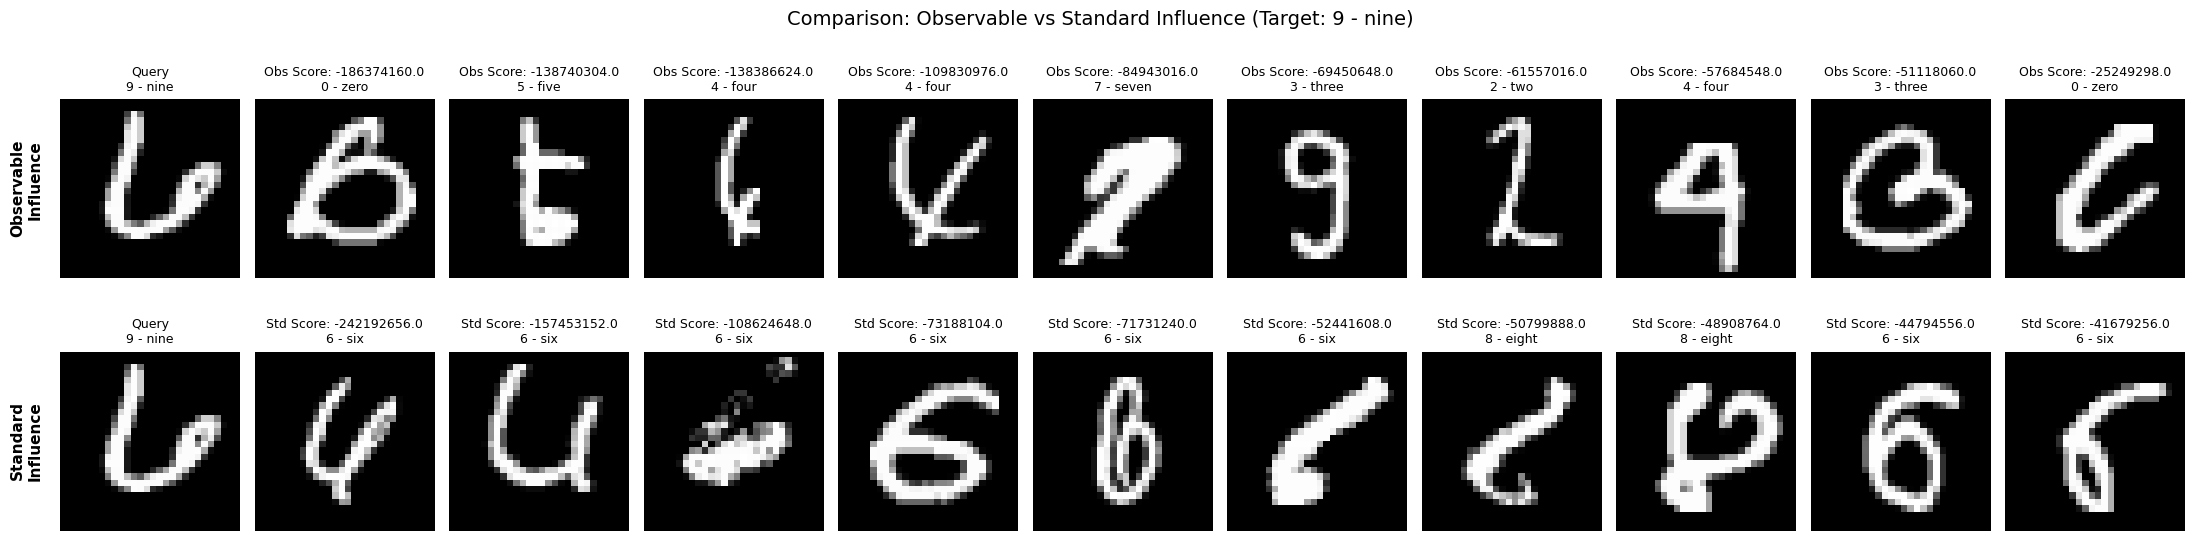


Observable top 10 indices: [33812, 25327, 27832, 13434, 25497, 20701, 22921, 20962, 37184, 47047]
Standard top 10 indices: [19599, 16518, 6118, 9591, 48217, 14498, 16472, 25809, 51992, 2883]
Overlap: 0 images


In [22]:
# Compare top influential images
fig, axs = plt.subplots(nrows=2, ncols=11, figsize=(22, 6))
fig.suptitle(f"Comparison: Observable vs Standard Influence (Target: {test_ds.classes[y_star]})", fontsize=14)

# Top 10 from observable influence
obs_top_idxs = observable_scores.argsort()[:10]
axs[0, 0].imshow(prepare_img(x_star))
axs[0, 0].axis("off")
axs[0, 0].set_title(f"Query\n{test_ds.classes[y_star]}", fontsize=9)

for ii, idx in enumerate(obs_top_idxs):
    img, label = train_ds[idx]
    axs[0, ii + 1].imshow(prepare_img(img))
    axs[0, ii + 1].axis("off")
    axs[0, ii + 1].set_title(f"Obs Score: {observable_scores[idx]:.1f}\n{test_ds.classes[label]}", fontsize=9)

axs[0, 0].text(-0.1, 0.5, 'Observable\nInfluence', transform=axs[0, 0].transAxes, 
               fontsize=11, va='center', ha='right', rotation=90, weight='bold')

# Top 10 from standard influence  
std_top_idxs = standard_scores.argsort()[:10]
axs[1, 0].imshow(prepare_img(x_star))
axs[1, 0].axis("off")
axs[1, 0].set_title(f"Query\n{test_ds.classes[y_star]}", fontsize=9)

for ii, idx in enumerate(std_top_idxs):
    img, label = train_ds[idx]
    axs[1, ii + 1].imshow(prepare_img(img))
    axs[1, ii + 1].axis("off")
    axs[1, ii + 1].set_title(f"Std Score: {standard_scores[idx]:.1f}\n{test_ds.classes[label]}", fontsize=9)

axs[1, 0].text(-0.1, 0.5, 'Standard\nInfluence', transform=axs[1, 0].transAxes,
               fontsize=11, va='center', ha='right', rotation=90, weight='bold')

plt.tight_layout()
plt.show()

print(f"\nObservable top 10 indices: {obs_top_idxs.tolist()}")
print(f"Standard top 10 indices: {std_top_idxs.tolist()}")
print(f"Overlap: {len(set(obs_top_idxs.tolist()) & set(std_top_idxs.tolist()))} images")